In [ ]:
pip install tensorflow

In [2]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../dataset_metadata.csv")
print("Total samples:", len(df))
df.head()

Total samples: 1440


,path,emotion,actor
0,../dataset\Actor_01\03-01-01-01-01-01-01.wav,neutral,Actor_01
1,../dataset\Actor_01\03-01-01-01-01-02-01.wav,neutral,Actor_01
2,../dataset\Actor_01\03-01-01-01-02-01-01.wav,neutral,Actor_01
3,../dataset\Actor_01\03-01-01-01-02-02-01.wav,neutral,Actor_01
4,../dataset\Actor_01\03-01-02-01-01-01-01.wav,calm,Actor_01


In [4]:


def add_noise(audio):
    noise = np.random.normal(0,0.02, audio.shape)
    return audio + noise

def pitch_shift(audio, sr):
    return librosa.effects.pitch_shift(audio,sr=sr,n_steps=2)

def extract_logmel_from_audio(audio, sr):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        hop_length=512
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel

In [5]:
#Extraction of spectogram dataset + adding padding
X=[]
y=[]
max_len = 128
for index, row in tqdm(df.iterrows(), total=len(df)):
    audio, sr = librosa.load(row["path"], sr=22050)
    #Original + Augmented versions
    variants = [audio, add_noise(audio), pitch_shift(audio, sr)]
    for variant in variants:
        spec = extract_logmel_from_audio(variant, sr)
        #pad or truncate for inputs to have identical shape
        if spec.shape[1] < max_len:
            pad_width = max_len - spec.shape[1]
            spec = np.pad(spec, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            spec = spec[:, :max_len]
        X.append(spec)
        y.append(row["emotion"])

X = np.array(X)
y = np.array(y)

print("Shape:",X.shape)

  0%|                                                  | 0/1440 [00:00<?, ?it/s]C:\ddata\git program\speech-emotion-recognition\ser_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|███████████████████████████████████████| 1440/1440 [07:11<00:00,  3.34it/s]


Shape: (4320, 128, 128)


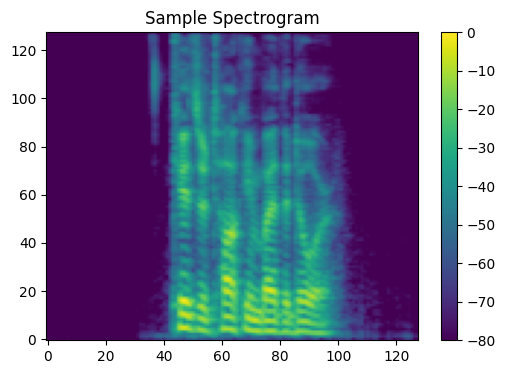

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.imshow(X[0], aspect='auto', origin='lower')
plt.colorbar()
plt.title("Sample Spectrogram")
plt.show()


In [7]:
print("Min value:", np.min(X))
print("Max value:", np.max(X))
print("Mean value:", np.mean(X))

Min value: -80.0
Max value: 0.0
Mean value: -48.91614648212177


In [8]:
X = X[..., np.newaxis]
# for i in range(len(X)):
#     X[i] = (X[i] - np.min(X[i])) / (np.max(X[i]) - np.min(X[i]) + 1e-6)
# X = X/80.0
# mean = np.mean(X)
# std = np.std(X)

# X = (X - mean) / (std + 1e-6)
print("New Shape:", X.shape)

New Shape: (4320, 128, 128, 1)


In [9]:
#encoding labels
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)
print("Label Shape:", y_categorical.shape)

Label Shape: (4320, 8)


In [10]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, stratify=y_encoded, random_state=42)
print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (3456, 128, 128, 1)
Test: (864, 128, 128, 1)


In [11]:
#normalization
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / (std + 1e-6)
X_test = (X_test - mean) / (std + 1e-6)

print("Train Mean:", np.mean(X_train))
print("Train Std:", np.std(X_train))


Train Mean: -3.2901921927693443e-15
Train Std: 0.9999999560653656


In [12]:
#building the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [13]:

model = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),

    Dense(64, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(8, activation='softmax')
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape            ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)    │           160 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)      │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)      │         4,640 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)      │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)      │        18,496 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)      │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)           │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)              │       802,880 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)              │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)               │           520 │
└─────────────────────────────────┴─────────────────────────┴───────────────┘

 Total params: 826,696 (3.15 MB)

 Trainable params: 826,696 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#model compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [16]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=32, 
                   callbacks=[early_stop]
                   )


Epoch 1/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.1852 - loss: 2.1004 - val_accuracy: 0.1936 - val_loss: 2.0000
Epoch 2/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.2565 - loss: 1.9491 - val_accuracy: 0.3179 - val_loss: 1.8422
Epoch 3/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.3014 - loss: 1.8374 - val_accuracy: 0.3743 - val_loss: 1.7360
Epoch 4/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 160ms/step - accuracy: 0.3488 - loss: 1.7332 - val_accuracy: 0.4176 - val_loss: 1.5913
Epoch 5/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.3679 - loss: 1.6708 - val_accuracy: 0.4754 - val_loss: 1.5124
Epoch 6/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.3976 - loss: 1.5863 - val_accuracy: 0.5289 - val_loss: 1.4895
Epoch 7/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.4298 - loss: 1.5136 - val_accuracy: 0.5145 - val_loss: 1.4544
Epoch 8/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.4613 - loss: 1.4486 - val_accu

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7234 - loss: 0.9196
Test Accuracy: 0.7233796119689941


In [33]:
# Save model
model.save("cnn_ser_model.keras")

# Save label encoder
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Save normalization values
import numpy as np
np.save("normalization_values.npy", np.array([mean, std]))

print("Model and preprocessing files saved successfully.")

Model and preprocessing files saved successfully.


In [18]:
#testing with audio sets
def predict_emotion(file_path, model, le, mean, std):
    
    # Load audio
    audio, sr = librosa.load(file_path, sr=22050)
    
    # Extract log-mel
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        hop_length=512
    )
    
    log_mel = librosa.power_to_db(mel, ref=np.max)
    
    # Pad or truncate
    max_len = 128
    
    if log_mel.shape[1] < max_len:
        pad_width = max_len - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        log_mel = log_mel[:, :max_len]
    
    # Add channel dimension
    log_mel = log_mel[..., np.newaxis]
    
    # Normalize using training mean/std
    log_mel = (log_mel - mean) / (std + 1e-6)
    
    # Add batch dimension
    log_mel = np.expand_dims(log_mel, axis=0)
    
    # Predict
    prediction = model.predict(log_mel)
    
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)
    
    emotion = le.inverse_transform([predicted_class])[0]
    
    return emotion, confidence

In [28]:
#picking random audio from dataset
import random
from IPython.display import Audio, display

# Pick random file
random_index = random.randint(0, len(df)-1)
file_path = df.iloc[random_index]["path"]
actual_emotion = df.iloc[random_index]["emotion"]

print("Playing Audio:")
display(Audio(file_path))

# Predict using saved mean and std
predicted_emotion, confidence = predict_emotion(
    file_path,
    model,
    le,
    mean,
    std
)

print("\nFile:", file_path)
print("Actual Emotion:", actual_emotion)
print("Predicted Emotion:", predicted_emotion)
print("Confidence:", confidence)

Playing Audio:


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

File: ../dataset\Actor_06\03-01-05-01-02-01-06.wav
Actual Emotion: angry
Predicted Emotion: angry
Confidence: 0.9898465


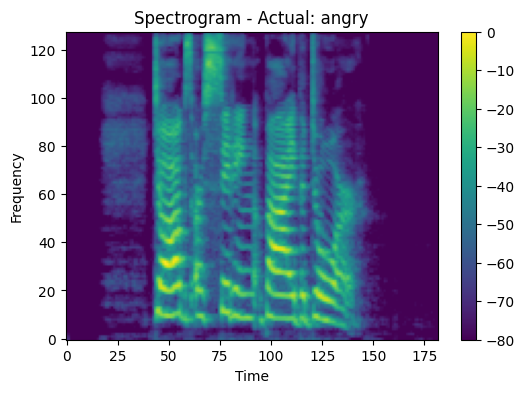

In [29]:
audio, sr = librosa.load(file_path, sr=22050)
mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
log_mel = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(6,4))
plt.imshow(log_mel, aspect='auto', origin='lower')
plt.colorbar()
plt.title(f"Spectrogram - Actual: {actual_emotion}")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

In [30]:
for i in range(5):
    random_index = random.randint(0, len(df)-1)
    file_path = df.iloc[random_index]["path"]
    actual = df.iloc[random_index]["emotion"]
    
    predicted, conf = predict_emotion(
        file_path,
        model,
        le,
        mean,
        std
    )
    
    print("\nActual:", actual)
    print("Predicted:", predicted)
    print("Confidence:", conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

Actual: calm
Predicted: calm
Confidence: 0.91344345
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

Actual: disgust
Predicted: disgust
Confidence: 0.9999682
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step

Actual: fearful
Predicted: fearful
Confidence: 0.99962187
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

Actual: happy
Predicted: happy
Confidence: 0.9100579
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step

Actual: happy
Predicted: happy
Confidence: 0.9925565


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Get emotion labels
emotion_labels = le.classes_

# Classification report as dict
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=emotion_labels,
    output_dict=True
)

# Convert to DataFrame
cnn_report_df = pd.DataFrame(report_dict).transpose()
cnn_report_df["Model"] = "CNN"

cnn_report_df.head()

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


,precision,recall,f1-score,support,Model
angry,0.875000,0.791304,0.831050,115.0,CNN
calm,0.661654,0.765217,0.709677,115.0,CNN
disgust,0.803571,0.782609,0.792952,115.0,CNN
fearful,0.702479,0.739130,0.720339,115.0,CNN
happy,0.673077,0.608696,0.639269,115.0,CNN


In [63]:
cm = confusion_matrix(y_true, y_pred)

cm_data = []

for i, actual in enumerate(emotion_labels):
    for j, predicted in enumerate(emotion_labels):
        cm_data.append([
            actual,
            predicted,
            cm[i, j],
            "CNN"
        ])

cnn_cm_df = pd.DataFrame(
    cm_data,
    columns=["Actual", "Predicted", "Count", "Model"]
)

cnn_cm_df.head()

,Actual,Predicted,Count,Model
0,angry,angry,92,CNN
1,angry,calm,1,CNN
2,angry,disgust,6,CNN
3,angry,fearful,4,CNN
4,angry,happy,7,CNN


In [64]:
cnn_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]

accuracy_df = pd.DataFrame({
    "Model": ["CNN"],
    "Accuracy": [cnn_accuracy]
})

accuracy_df

,Model,Accuracy
0,CNN,0.731481


In [66]:
cnn_report_df.to_csv("cnn_classification_report.csv")
cnn_cm_df.to_csv("cnn_confusion_matrix.csv", index=False)
accuracy_df.to_csv("model_accuracy.csv", index=False)